# **Neural Networks** **ニューラルネットワーク入門**

<img src="https://upload.wikimedia.org/wikipedia/commons/3/3d/Neural_network.svg">


近年、私たちの身の回りにはAI技術がますます広がっています。その中心的な役割を担っているのが「**ニューラルネットワーク（Neural Network, NN）**」です。ニューラルネットワークは、人間の脳の神経回路（ニューロン）の仕組みに着想を得て開発された機械学習モデルであり、大量のデータから特徴やパターンを自動的に学習する能力を持っています。

ニューラルネットワークは、画像認識や音声認識、言語翻訳、医療診断、自動運転、さらには生成AI（画像・文章生成）など、さまざまな分野で幅広く活用されています。これらの分野では、人間が従来手作業で設計していた特徴抽出や判断のプロセスをニューラルネットワークが自動で学習し、高い精度で複雑なタスクをこなすことが可能になりました。

**なぜニューラルネットワークがこれほど注目されているのでしょうか？**

その理由の一つは、「**Big Data**」と「**計算資源**」の進化によって、大規模なネットワークを効率よく学習させられるようになったことです。さらに、ニューラルネットワークは**非線形な複雑な関係性も表現できる**ため、従来の機械学習手法では難しかった課題にもアプローチできるようになっています。

このノートブックでは、ニューラルネットワークの基本的な仕組みや考え方を、実際に手を動かしながら学んでいきます。





## **参考**

ニューラルネットワークについてさらに理解を深めたい方のために、以下の**リソース**をおすすめします：

https://jalammar.github.io/visual-interactive-guide-basics-neural-networks/　（英語）

https://chokkan.github.io/deeplearning/demo-slp.html （ビジュアルdemo）

https://chokkan.github.io/mlnote/classification/03nn.html　（日本語）

## **論理演算とニューラルネットワーク**

コンピュータの計算の基本は、AND、OR、NOT、XORなどの論理演算です。
これらは、電気回路やデジタル回路だけでなく、実は**ニューラルネットワーク（人工ニューラルネットワーク）**の世界でも非常に大切な役割を持っています。

ニューラルネットワークは、人間の脳の神経細胞（ニューロン）を模した数理モデルですが、
単純な仕組みでさまざまな論理回路の動作を再現することができることが知られています。

#### **今回のコースでは、**

- 論理演算（AND, OR, NANDなど）をニューラルネットワークでどう表現できるのか

- パーセプトロンやロジスティック回帰による単純な学習

- 多層ネットワークと勾配降下法によるより複雑な論理の学習

- 学習プロセスの可視化

を実際に手を動かしながら学んでいきます！💪 📕

# ライブラリのインポート

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier

## **ANDゲートとXORゲートをニューラルネットワークで実現できるか試してみよう**

このコードでは、ロジスティック回帰（SGDClassifier）を使って、ANDゲートやORゲートといった論理演算を機械学習で学習させる方法を体験します。

ロジスティック回帰はシンプルな線形分類器ですが、論理演算のような基本問題を機械学習でどう扱えるか、体験してみましょう！

#### **AND Gate**

In [ ]:
# 入力パターン
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
# ANDゲートの出力ラベル
Y = np.array([0, 0, 0, 1])
# ANDゲートを学習するためのSGD分類器を定義（損失関数はlog_loss＝ロジスティック回帰）
mAND = SGDClassifier(loss='log_loss')
# 学習を実行
mAND.fit(X, Y)

SGDClassifier(loss='log_loss')

In [ ]:
# 学習したモデルを使って各入力パターンの予測を行う
mAND.predict(X)

array([0, 0, 0, 1])

#### **OR Gate**

In [ ]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
Y = np.array([0, 1, 1, 1])
mOR = SGDClassifier(loss='log_loss')
mOR.fit(X, Y)

SGDClassifier(loss='log_loss')

In [ ]:
mOR.predict(X)

array([0, 1, 1, 1])

## **ORゲートをシンプルなニューラルネットワークで表現してみよう**

以下のコードでは、シンプルなニューラルネットワークを使って論理和（OR）演算を表現します。

入力は2ビット`（x1, x2）`です。

重みを` [1, 1]`、バイアスを` -0.5 `に設定します。

`np.heaviside` 関数を使い、出力が`0`より大きければ`1`、そうでなければ0となります。

このネットワークは、入力のどちらか一方が`1`であれば出力`1`、両方`0`なら出力`0`、つまりORゲートになります。

In [ ]:
# 隠れ層の重みを定義（2つの隠れユニット）
w_xh = np.array([
    [1, 0],   # 隠れユニット1はx1を見る
    [0, 1]    # 隠れユニット2はx2を見る
])  # shape: (2, 2) のため、x @ w_xh.T が動作する

b_xh = np.array([0, 0])  # バイアスは不要

# 隠れ層から出力層への重み
w_hy = np.array([1, 1])  # 両方の隠れユニットの出力を「OR」として合成
b_hy = np.array([-0.5])  # 出力層のバイアス

In [ ]:
# 入力パターン
x = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
# 隠れ層の出力を計算
h = np.heaviside(x @ w_xh.T + b_xh, 0)
h

array([[0., 0.],
       [0., 1.],
       [1., 0.],
       [1., 1.]])

In [ ]:
# 順伝播（フォワードパス）：出力層の出力を計算
y = np.heaviside(h @ w_hy + b_hy, 0)
y

array([0., 1., 1., 1.])

💡「重み」と「バイアス」を適切に設定するだけで、ニューラルネットワークはさまざまな論理演算（AND,OR、NOTなど）を表現できます。しかし、実際には「適切な重み」を見つけることは簡単ではありません。そこで今回は、ニューラルネットワークの基礎となっている有名なアルゴリズム「**パーセプトロンアルゴリズム** 」 を用いて、最適な重みを自動的に見つけてみましょう！

## **パーセプトロンアルゴリズムを用いてORを学習しましょう**

この例では、バイアス項を含めるため、入力ベクトル` x `の最後の要素を常に`1`にしています。

重みベクトル` w` も初期値はすべて`0`からスタートします。

**学習率（eta）**は`0.5`に設定しています。




In [ ]:
# 学習データ
x = np.array([
    [0, 0, 1],
    [0, 1, 1],
    [1, 0, 1],
    [1, 1, 1]
])

# 正解ラベル（ORの真理値表）
y = np.array([0, 1, 1, 1])

# 重みの初期値（全て0でスタート）
w = np.array([0.0, 0.0, 0.0])

# 学習率
eta = 0.5

#### **パーセプトロンアルゴリズムによる重み更新**

- 学習回数（ここでは50回）だけ繰り返します。

- 各ステップでデータを1つランダムに選びます。

- 現在の重みで予測を行い、誤差（正解ラベルと予測の差）を計算します。

- 誤差に応じて重みベクトル` w` を更新します。

In [ ]:
# 学習過程の損失（誤分類数）を記録するリスト
loss_list = []

for t in range(100):
    # インスタンスのインデックス（i）をランダムに選ぶ
    i = random.choice(range(len(y)))
    # 現在のパラメータwで、インスタンスx[i]のラベルを予測
    y_pred = np.heaviside(np.dot(x[i], w), 0)
    # 選んだインスタンスや現在のパラメータなどを表示
    print(f'#{t}: i={i}, x={x[i]}, w={w}, y={y[i]}, y_pred={y_pred}, y_err={y[i] - y_pred}')
    # パラメータを更新
    w += (y[i] - y_pred) * eta * x[i]

    y_pred_all = np.heaviside(np.dot(x, w), 0)
    loss = np.sum(y != y_pred_all)  # 誤分類の数
    loss_list.append(loss)

#0: i=0, x=[0 0 1], w=[0. 0. 0.], y=0, y_pred=0.0, y_err=0.0
#1: i=1, x=[0 1 1], w=[0. 0. 0.], y=1, y_pred=0.0, y_err=1.0
#2: i=0, x=[0 0 1], w=[0.  0.5 0.5], y=0, y_pred=1.0, y_err=-1.0
#3: i=2, x=[1 0 1], w=[0.  0.5 0. ], y=1, y_pred=0.0, y_err=1.0
#4: i=1, x=[0 1 1], w=[0.5 0.5 0.5], y=1, y_pred=1.0, y_err=0.0
#5: i=2, x=[1 0 1], w=[0.5 0.5 0.5], y=1, y_pred=1.0, y_err=0.0
#6: i=1, x=[0 1 1], w=[0.5 0.5 0.5], y=1, y_pred=1.0, y_err=0.0
#7: i=2, x=[1 0 1], w=[0.5 0.5 0.5], y=1, y_pred=1.0, y_err=0.0
#8: i=3, x=[1 1 1], w=[0.5 0.5 0.5], y=1, y_pred=1.0, y_err=0.0
#9: i=1, x=[0 1 1], w=[0.5 0.5 0.5], y=1, y_pred=1.0, y_err=0.0
#10: i=1, x=[0 1 1], w=[0.5 0.5 0.5], y=1, y_pred=1.0, y_err=0.0
#11: i=2, x=[1 0 1], w=[0.5 0.5 0.5], y=1, y_pred=1.0, y_err=0.0
#12: i=2, x=[1 0 1], w=[0.5 0.5 0.5], y=1, y_pred=1.0, y_err=0.0
#13: i=0, x=[0 0 1], w=[0.5 0.5 0.5], y=0, y_pred=1.0, y_err=-1.0
#14: i=1, x=[0 1 1], w=[0.5 0.5 0. ], y=1, y_pred=1.0, y_err=0.0
#15: i=0, x=[0 0 1], w=[0.5 0.5 0. ], y

`loss_list` に、各ステップごとの誤分類数を記録しています。

学習が進むと、誤分類数が減って0になる様子がグラフで観察できます。

## **学習済みパーセプトロンの性能を確認しよう**
パーセプトロンで学習したパラメータが、ORゲートを正しく判定できるかどうか、全ての入力パターンについて予測結果を確認してみましょう。

In [ ]:
# テストデータ（バイアス項を含む）
test_x = np.array([
    [0, 0, 1],
    [0, 1, 1],
    [1, 0, 1],
    [1, 1, 1]
])

# 正解ラベル（ORの真理値表）
test_y = np.array([0, 1, 1, 1])

# 各入力パターンについて予測結果と正解を表示
for i in range(len(test_x)):
    y_pred = np.heaviside(np.dot(test_x[i], w), 0)
    print(f"x={test_x[i][:2]} → 予測={int(y_pred)}, 正解={test_y[i]}")

x=[0 0] → 予測=0, 正解=0
x=[0 1] → 予測=1, 正解=1
x=[1 0] → 予測=1, 正解=1
x=[1 1] → 予測=1, 正解=1


## **最後に、学習過程をグラフで可視化してみましょう**
パーセプトロンの学習が進むにつれて、誤分類数がどのように変化したかをグラフで確認します。



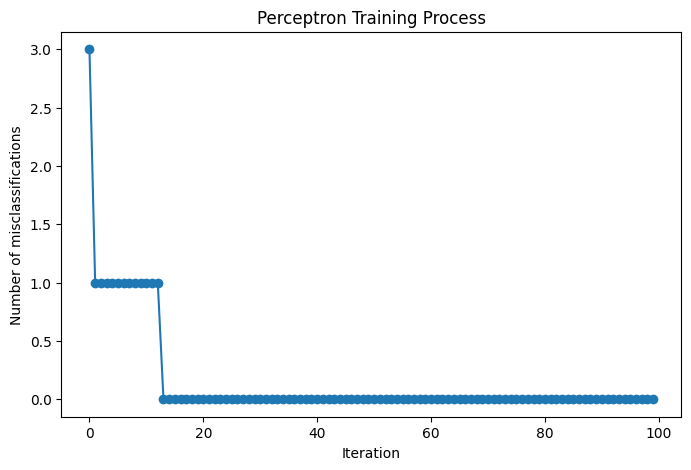

In [ ]:
# 損失（誤分類数）の推移をプロット
plt.figure(figsize=(8,5))
plt.plot(loss_list, marker="o")
plt.xlabel("Iteration")
plt.ylabel("Number of misclassifications")
plt.title("Perceptron Training Process")
plt.show()

このグラフは、パーセプトロンアルゴリズムでORゲートを学習した時の「誤分類数（Number of misclassifications）」の推移を示しています。

学習を進めることで徐々に誤分類数が減少し、最終的には0になっています。
これは、パーセプトロンが「ORゲート」の重みをうまく学習し、すべての入力パターンで正しい出力をできるようになったことを示しています。

パーセプトロンは**線形分離可能な問題（今回のORゲートなど）**であれば、必ず誤分類がゼロになります。

💡 しかし、**XORやNANDといったゲートは、シンプルな1層のパーセプトロンでは学習することができません。**　これは、これらの論理回路が**線形分離不可能な問題**であるためです。

この違いを体験するために、今回の演習ではNANDゲートの学習にも挑戦していきしょう！💪